In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully!")

Libraries loaded successfully!


Create a realistic student-wellness dataset

In [2]:
np.random.seed(42)

n = 1500

data = pd.DataFrame({
    "study_hours": np.random.uniform(1, 10, n),
    "sleep_hours": np.random.uniform(4, 9, n),
    "screen_time": np.random.uniform(2, 12, n),
    "exercise_hours": np.random.uniform(0, 7, n),
    "academic_pressure": np.random.randint(1, 11, n),
    "social_support": np.random.randint(1, 11, n),
    "financial_stress": np.random.randint(1, 11, n),
    "attendance": np.random.uniform(50, 100, n),
    "age": np.random.randint(18, 26, n)
})

# Generate a wellness score for educational modelling
noise = np.random.normal(0, 5, n)

data["wellness_score"] = (
    45
    + 2.0 * data["sleep_hours"]
    + 1.5 * data["exercise_hours"]
    + 0.25 * data["attendance"]
    + 1.5 * data["social_support"]
    - 2.2 * data["academic_pressure"]
    - 1.5 * data["financial_stress"]
    - 0.8 * data["screen_time"]
    + noise
)

# Keep score within 0–100
data["wellness_score"] = data["wellness_score"].clip(0, 100)

data.head()

,study_hours,sleep_hours,screen_time,exercise_hours,academic_pressure,social_support,financial_stress,attendance,age,wellness_score
0,4.370861,6.595409,8.727030,4.195095,1,7,5,59.657888,23,69.486354
1,9.556429,6.395909,9.966814,3.595955,1,3,2,83.396224,24,65.361483
2,7.587945,4.128210,4.504679,2.017292,3,4,7,54.673397,21,54.037323
3,6.387926,5.706239,8.248741,0.045251,5,10,6,75.392507,18,55.786404
4,2.404168,5.900978,7.717460,3.473675,3,7,1,58.111777,23,86.439329


Why this is useful
You now have an actual dataset with:
- sleep
- study hours
- screen time
- exercise
- academic pressure
- social support
- financial stress
- attendance
- age
and a target:
wellness_score

**Explore the data**

In [3]:
print("Dataset shape:", data.shape)

print("\nMissing values:")
print(data.isnull().sum())

print("\nDataset statistics:")
display(data.describe())

Dataset shape: (1500, 10)

Missing values:
study_hours          0
sleep_hours          0
screen_time          0
exercise_hours       0
academic_pressure    0
social_support       0
financial_stress     0
attendance           0
age                  0
wellness_score       0
dtype: int64

Dataset statistics:


,study_hours,sleep_hours,screen_time,exercise_hours,academic_pressure,social_support,financial_stress,attendance,age,wellness_score
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,5.494214,6.502147,6.893663,3.494845,5.547333,5.515333,5.545333,75.072434,21.570667,64.266475
std,2.646136,1.446878,2.851794,2.027628,2.933513,2.935219,2.836896,14.380798,2.302290,11.938481
min,1.041688,4.000058,2.000307,0.001589,1.000000,1.000000,1.000000,50.009260,18.000000,26.707481
25%,3.137895,5.286998,4.414996,1.739337,3.000000,3.000000,3.000000,63.027317,19.000000,56.448589
50%,5.559056,6.525006,6.875498,3.425920,6.000000,6.000000,6.000000,74.837348,22.000000,63.927679
75%,7.783024,7.772296,9.292598,5.260619,8.000000,8.000000,8.000000,87.150317,24.000000,72.205536
max,9.997459,8.991738,11.995577,6.995452,10.000000,10.000000,10.000000,99.981781,25.000000,99.895034


**Correlation analysis**

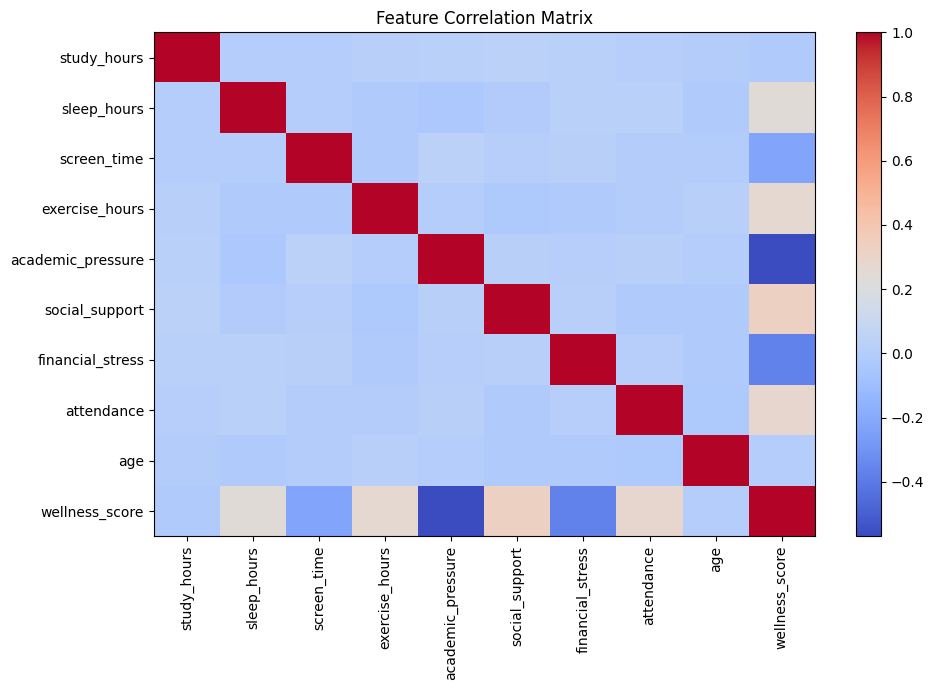

In [4]:
plt.figure(figsize=(10, 7))

correlation = data.corr(numeric_only=True)

plt.imshow(correlation, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

**Prepare the data**

In [5]:
X = data.drop("wellness_score", axis=1)
y = data["wellness_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1200
Testing samples: 300


**Train multiple ML models**

In [6]:
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )
}

**Compare the models**

In [7]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "RMSE"
)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4.341578,5.372646,0.810296
2,Gradient Boosting,4.832697,5.973047,0.765528
1,Random Forest,5.228504,6.644336,0.709863


**Select the best model**

In [8]:
best_model_name = results_df.loc[
    results_df["RMSE"].idxmin(),
    "Model"
]

best_model = models[best_model_name]

print("Selected model:", best_model_name)

Selected model: Linear Regression


**Feature importance**

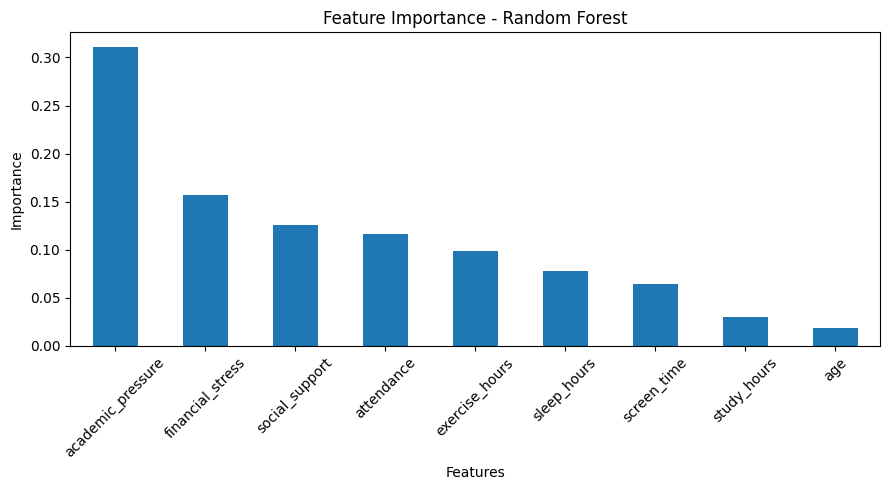

In [9]:
rf = models["Random Forest"]

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))

importance.plot(kind="bar")

plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Optimization**

In [10]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
final_model = optimized_model

def predict_wellness(
    study_hours,
    sleep_hours,
    screen_time,
    exercise_hours,
    academic_pressure,
    social_support,
    financial_stress,
    attendance,
    age
):

    input_data = pd.DataFrame({
        "study_hours": [study_hours],
        "sleep_hours": [sleep_hours],
        "screen_time": [screen_time],
        "exercise_hours": [exercise_hours],
        "academic_pressure": [academic_pressure],
        "social_support": [social_support],
        "financial_stress": [financial_stress],
        "attendance": [attendance],
        "age": [age]
    })

    prediction = final_model.predict(input_data)[0]

    return round(float(prediction), 2)
grid_search.fit(X_train, y_train)

optimized_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [11]:
optimized_predictions = optimized_model.predict(X_test)

optimized_mae = mean_absolute_error(
    y_test,
    optimized_predictions
)

optimized_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        optimized_predictions
    )
)

optimized_r2 = r2_score(
    y_test,
    optimized_predictions
)

print("Optimized Model Results")
print("-----------------------")
print("MAE :", round(optimized_mae, 3))
print("RMSE:", round(optimized_rmse, 3))
print("R2  :", round(optimized_r2, 3))

Optimized Model Results
-----------------------
MAE : 5.229
RMSE: 6.644
R2  : 0.71


**Create a prediction function**

In [12]:
final_model = optimized_model

def predict_wellness(
    study_hours,
    sleep_hours,
    screen_time,
    exercise_hours,
    academic_pressure,
    social_support,
    financial_stress,
    attendance,
    age
):

    input_data = pd.DataFrame({
        "study_hours": [study_hours],
        "sleep_hours": [sleep_hours],
        "screen_time": [screen_time],
        "exercise_hours": [exercise_hours],
        "academic_pressure": [academic_pressure],
        "social_support": [social_support],
        "financial_stress": [financial_stress],
        "attendance": [attendance],
        "age": [age]
    })

    prediction = final_model.predict(input_data)[0]

    return round(float(prediction), 2)

**Create a prediction function**

In [13]:
final_model = optimized_model

def predict_wellness(
    study_hours,
    sleep_hours,
    screen_time,
    exercise_hours,
    academic_pressure,
    social_support,
    financial_stress,
    attendance,
    age
):

    input_data = pd.DataFrame({
        "study_hours": [study_hours],
        "sleep_hours": [sleep_hours],
        "screen_time": [screen_time],
        "exercise_hours": [exercise_hours],
        "academic_pressure": [academic_pressure],
        "social_support": [social_support],
        "financial_stress": [financial_stress],
        "attendance": [attendance],
        "age": [age]
    })

    prediction = final_model.predict(input_data)[0]

    return round(float(prediction), 2)

In [14]:
score = predict_wellness(
    study_hours=6,
    sleep_hours=7,
    screen_time=5,
    exercise_hours=3,
    academic_pressure=4,
    social_support=8,
    financial_stress=3,
    attendance=85,
    age=21
)

print("Predicted Wellness Score:", score)

Predicted Wellness Score: 78.84


**Save the model**

In [15]:
import joblib

joblib.dump(
    final_model,
    "student_wellness_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


# Conclusion

This project developed an end-to-end machine learning pipeline for educational prediction of a student wellness score.

The project covered:

- Data generation and preprocessing
- Exploratory data analysis
- Feature engineering
- Multiple regression models
- Model evaluation using MAE, RMSE and R²
- Random Forest feature importance
- Hyperparameter optimization using GridSearchCV
- Model serialization using Joblib
- Prediction of wellness scores for new inputs

The system is intended for educational purposes and should not be used as a medical or psychological diagnostic system.